# Imagecollections (ενότητα 2)

<a href="https://githubtocolab.com/kokkytos/gee/blob/main/Lesson6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [ ]:
import ee # Google Earth Engine Python Client
import geemap # frontend του ee Google Earth Engine
from pathlib import Path # διαχείριση αρχείων
import os # για την διαχείριση περιβάλλοντος και αρχείων
from dotenv import load_dotenv # για την φόρτωση μεταβλητών περιβάλλοντος από .env αρχεία
import geopandas as gpd # για την διαχείριση γεωχωρικών δεδομένων
import pandas as pd # για την διαχείριση δεδομένων
import pprint # για την όμορφη εκτύπωση δομών δεδομένων

In [2]:
# έλεγχος αν το notebook τρέχει στο google colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Colab\ Notebooks/gee
except:
  print("Παρακαλώ εκτελέστε το notebook στο Google Colab")

Παρακαλώ εκτελέστε το notebook στο Google Colab


In [3]:

# Load environment variables from .env file
load_dotenv()
project_id = os.getenv('project_id')


# gee authentication
ee.Authenticate()
ee.Initialize(project=project_id)



OUTPUT_DIR = Path("output")


In [4]:
# ΠΕ Ελλάδας (2021)
pe_shp_path = 'data/RegionalUnits2021/RegionalUnits2021.shp'

# ανάγνωση σαν geopandas dataframe
gdf = gpd.read_file(pe_shp_path)

# μετατροπή σε WGS84
gdf = gdf.to_crs(epsg=4326)

# επιλογή της Πελοποννήσου
gdf = gdf[gdf['CODE'].isin(['37', '39','40','41','42','43','44','52'])]

# Απλοποίησε τη γεωμετρία (το 0.001 είναι μια καλή αρχή για μοίρες)
# Preserve_topology=True διασφαλίζει ότι δεν θα "χαλάσουν" τα πολύγωνα
gdf['geometry'] = gdf.simplify(0.001, preserve_topology=True)

# Μετατροπή σε FeatureCollection
RegionalUnits2021 = geemap.geopandas_to_ee(gdf)

# πλαίσιο των ορίων της περιοχής
bbox = RegionalUnits2021.bounds()



In [5]:
Map = geemap.Map()
Map.addLayer(RegionalUnits2021, {}, 'Περ. Ενότητες')
Map.centerObject(RegionalUnits2021, 8)
Map

Map(center=[37.48516614620398, 22.303946498694245], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
# ημερομηνία έναρξης και λήξης της χρονοσειράς
start_date = ee.Date.fromYMD(2023, 1, 1)
end_date = ee.Date.fromYMD(2026, 1, 1)

# Ορισμός της Συλλογής USGS Landsat 8 Level 2, Collection 2, Tier 1 και Φιλτράρισμα
L8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") # https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2
              .filterBounds(bbox) # Φιλτράρισμα με βάση τα όρια της Αττικής
              .filterDate(start_date, end_date) # Φιλτράρισμα με βάση το εύρος ημερομηνιών (The end date is exclusive)
           ) 


def add_year_month(image):
    # Λήψη της ημερομηνίας από το system:time_start
    date = ee.Date(image.get('system:time_start')) # Το system:time_start είναι Unix Timestamp. Με την ee.Date() μετατρέπεται σε ημερομηνία που μπορούμε να εξάγουμε το έτος.
    year =  date.get('year') # εξαγωγή του έτους
    month = date.get('month') # εξαγωγή του έτους
    # Προσθήκη των ιδιοτήτων 'year' και 'month' στην εικόνα
    return image.set({
        'year': year,
        'month': month
    })

# εφαρμογή της συνάρτησης add_year σε κάθε εικόνα της συλλογής L8
L8 = L8.map(add_year_month)



Με τον παρακάτω κώδικα επιβεβαιώνεται ότι πλέον οι εικόνες έχουν δύο νέα properties, το year και month

In [7]:
first_image = L8.first()
props = first_image.propertyNames().getInfo()
print("\nΔιαθέσιμες Ιδιότητες (Metadata Properties):")
pprint.pprint(props)



Διαθέσιμες Ιδιότητες (Metadata Properties):
['month',
 'year',
 'DATA_SOURCE_ELEVATION',
 'WRS_TYPE',
 'system:id',
 'REFLECTANCE_ADD_BAND_1',
 'REFLECTANCE_ADD_BAND_2',
 'DATUM',
 'REFLECTANCE_ADD_BAND_3',
 'REFLECTANCE_ADD_BAND_4',
 'REFLECTANCE_ADD_BAND_5',
 'REFLECTANCE_ADD_BAND_6',
 'REFLECTANCE_ADD_BAND_7',
 'system:footprint',
 'REFLECTIVE_SAMPLES',
 'system:version',
 'GROUND_CONTROL_POINTS_VERSION',
 'SUN_AZIMUTH',
 'DATA_SOURCE_TIRS_STRAY_LIGHT_CORRECTION',
 'UTM_ZONE',
 'DATE_ACQUIRED',
 'ELLIPSOID',
 'system:time_end',
 'DATA_SOURCE_PRESSURE',
 'LANDSAT_PRODUCT_ID',
 'STATION_ID',
 'TEMPERATURE_ADD_BAND_ST_B10',
 'DATA_SOURCE_REANALYSIS',
 'REFLECTANCE_MULT_BAND_7',
 'system:time_start',
 'REFLECTANCE_MULT_BAND_6',
 'L1_PROCESSING_LEVEL',
 'PROCESSING_SOFTWARE_VERSION',
 'L1_DATE_PRODUCT_GENERATED',
 'ORIENTATION',
 'REFLECTANCE_MULT_BAND_1',
 'WRS_ROW',
 'REFLECTANCE_MULT_BAND_3',
 'REFLECTANCE_MULT_BAND_2',
 'TARGET_WRS_ROW',
 'REFLECTANCE_MULT_BAND_5',
 'REFLECTANCE_MUL

In [8]:
# Φιλτράρισμα για εικόνες με νεφοκάλυψη < 5% και SUN_ELEVATION > 35
# L8 = L8.filter(ee.Filter.lt('CLOUD_COVER', 5))\
#              .filter(ee.Filter.gt('SUN_ELEVATION', 35))


# συνάρτηση για εφαρμογή των συντελεστών (scale factors) για τα οπτικά και θερμικά κανάλια
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )

# Εφαρμογή των συντελεστών κλίμακας (scale factors) στην εικόνα του διάμεσου
L8 =  L8.map(apply_scale_factors)


def maskL8sr(image):
  # Bitmasks για την band QA_PIXEL
  FillBitMask = 1 << 0
  DilatedCloudBitMask = 1 << 1
  cloudsBitMask = 1 << 3
  cloudShadowBitMask = 1 << 4
  snowsBitMask = 1 << 5
  WaterBitMask = 1 << 7
  
  # λήψη της band QA_PIXEL που περιέχει τις πληροφορίες για τα σύννεφα, τη σκιά σύννεφου, το χιόνι, το νερό και τα έγκυρα δεδομένα
  qa = image.select('QA_PIXEL')

  # όλα τα bitmask πρέπει να είναι 0 για να θεωρηθεί το pixel καθαρό (clear)
  # αποδίδειται ένα mask όπου τα pixels που έχουν κάποιο από τα bitmask ενεργοποιημένα (δηλαδή δεν είναι καθαρά) θα έχουν τιμή 0 
  # και τα καθαρά pixels θα έχουν τιμή 1
  mask = (qa.bitwiseAnd(cloudShadowBitMask).eq(0)  #  eq 0 σημαίνει ότι δεν υπάρχει σκιά σύννεφου
    .And(qa.bitwiseAnd(cloudsBitMask).eq(0))  # eq 0 σημαίνει ότι δεν υπάρχει σύννεφο
    .And(qa.bitwiseAnd(snowsBitMask).eq(0)) # eq 0 σημαίνει ότι δεν υπάρχει χιόνι
    .And(qa.bitwiseAnd(FillBitMask).eq(0)) # eq 0 σημαίνει ότι τα δεδομένα ειναι έγκυρα
    .And(qa.bitwiseAnd(DilatedCloudBitMask).eq(0)) # eq 0 σημαίνει ότι δεν υπάρχει διευρυμένο σύννεφο
    .And(qa.bitwiseAnd(WaterBitMask).eq(0))) # eq 0 σημαίνει ότι δεν υπάρχει νερό
  
  
  saturationMask = image.select('QA_RADSAT').eq(0); # eq 0 σημαίνει ότι δεν υπάρχει κορεσμός ακτινοβολίας (radiometric saturation)
  

  # συνδυασμός των δύο masks:
  # για τα σύννεφα, τη σκιά σύννεφου, το χιόνι, το νερό και τα έγκυρα δεδομένα,
  #  καθώς και το mask για τον κορεσμό ακτινοβολίας
  combinedMask = mask.And(saturationMask).rename('mask')

  # εφαρμογή της ενιαίας mask στην εικόνα
  
  maskedimage = image.updateMask(combinedMask)

  # δημιουργία water band
  # Χρησιμοποιούμε .neq(0) γιατί το bitwiseAnd επιστρέφει 128 για το νερό (το water είναι bit 7 αρα 2^7 = 128)
  isWater = qa.bitwiseAnd(WaterBitMask).neq(0).rename('Water')
  
  # προσθήκη της band 'Water' που δείχνει αν το pixel είναι νερό ή όχι, με βάση το bitmask για το νερό στην band QA_PIXEL
  maskedimage = maskedimage.addBands([isWater,combinedMask]).copyProperties(image)
    
  return (maskedimage)

# εφαρμογή της συνάρτησης maskL8sr για την αφαίρεση των νεφών, 
# της σκιάς σύννεφου, του χιονιού, του νερού και των μη έγκυρων δεδομένων, καθώς και των pixels με κορεσμό ακτινοβολίας
L8_qa = L8.map(maskL8sr)


def clip_to_roi(image):
    return image.clip(RegionalUnits2021)


# αποκοπή (clip) αν και δεν ειναι απαραίτητο για τα επόμενα βήματα
#L8_qa_clipped = L8_qa.map(clip_to_roi)

L8_qa_clipped = L8_qa.select(['SR_B5', 'SR_B4', 'SR_B3', 'SR_B2'])


## Ετήσια composites

### Reducers

Στο Google Earth Engine (GEE), οι Reducers (περισσότερα [εδώ](https://developers.google.com/earth-engine/guides/reducers_intro)) αποτελούν τον θεμελιώδη τρόπο επεξεργασίας και συγκέντρωσης δεδομένων. Επειδή το Earth Engine διαχειρίζεται τεράστιες συλλογές πληροφοριών (όπως δορυφορικές εικόνες 20 ετών), χρειάζεται ένας τρόπος συγχώνευσης ή σύνοψης της πληροφορίας σε μια ενιαία τιμή, ένα στατιστικό στοιχείο ή ένα απλούστερο σχήμα.

Ένας Reducer λαμβάνει μια συλλογή εισόδων και επιστρέφει μία μόνο έξοδο. Αυτό συμβαίνει σε τρεις κύριες διαστάσεις:

1. **Μείωση στον Χρόνο (Temporal)**

Για παράδειγμα σε ένα ImageCollection (π.χ. 100 εικόνες Sentinel-2 από ένα αγροτεμάχιο κατά τη διάρκεια ενός έτους), μπορεί να χρησιμοποιηθεί ένας reducer για να δημιουργήθεί μια ενιαία "αντιπροσωπευτική" εικόνα για όλο το έτος ή 12 εικόνες, μία για κάθε μήνα. Πρόκειται δηλαδή για την διαδικασία δημιουργίας **composites** όπως συχνά αναφέρεται στα ΣΓΠ ή την τηλεπισκόπηση.

- συνήθεις Reducers: ee.Reducer.median() (διάμεσος), ee.Reducer.max() (μέγιστο), ee.Reducer.mean() (μέσος όρος).

- Αποτέλεσμα: Μια ενιαία εικόνα (ή 12 εικόνες όταν γίνεται ανά μήνα) όπου κάθε pixel είναι η διάμεση τιμή (ή μέσος όρο κτλ) και των 100 εικόνων.

2. **Μείωση στον Χώρο (Spatial)**

πχ σε μια εικόνα νυκτερινών φώτων suomi npp-VIIRS και μια συλλογή πολυγώνων (π.χ. τα όρια των πόλεων), χρησιμοποιείται ένας reducer για να υπολογιστεί ένα στατιστικό στοιχείο για τα πολύγωνα κάθε πόλης. Ουσιαστικά πρόκειται για τον υπολογισμό στατιστικών ζωνών (**zonal statistics**).

- συνήθεις Reducers: reduceRegion() ή reduceRegions() 

- Αποτέλεσμα: Ένας αριθμός για κάθε πόλη (π.χ. ο μέσος όρος ακτινοβολίας).

3. **Μείωση σε Γειτονιές (Neighborhoods)**

Η διαδικασία αυτή περιλαμβάνει focal (εστιακές) λειτουργίες γειτονιάς (neighborhood operations) ή τοπικά φίλτρα (local filters).

Αυτή η μέθοδος εξετάζει τα pixels που περιβάλλουν άμεσα ένα κεντρικό pixel.
Η διαδικασία χρησιμοποιεί ένα παράθυρο (συνήθως 3x3, 5x5 ή κύκλο). Για κάθε κελί της εισόδου, ο αλγόριθμος:

- Εξετάζει το κελί και τους γείτονές του.

- Εφαρμόζει έναν στατιστικό κανόνα (π.χ. μέσο όρο).

- Γράφει το αποτέλεσμα στο αντίστοιχο κελί ενός νέου ράστερ.

Η πιο συνηθισμένη συνάρτηση συνάρτηση είναι η reduceNeighborhood() και το αποτέλεσμα είναι μια εικόνα που έχει υποστεί "εξομάλυνση" ή "όξυνση" βάσει τοπικών στατιστικών.




Στο παρακάτω παράδειγμα θα χρησιμοποιήσουμε τους reducers για να υπολογίσουμε για τις μπάντες του imagecollection *L8_qa_clipped* τον μέσο και τον διάμεσο ανά έτος. Έτσι θα προκύψει μια εικόνα ανά έτος που θα έχει 6 μπαντες, 3 για τον μέσο όρο των 'SR_B4', 'SR_B3', 'SR_B2' και 3 για τον διάμεσο τους.

In [9]:
def create_annual_dual_composite(y):
    # Φιλτράρισμα για το συγκεκριμένο έτος
    year_colllection = L8_qa_clipped.filter(ee.Filter.eq('year', y))
    
    # Υπολογισμός Median και Mean
    # Προσθέτουμε suffix (επίθεμα) για να ξεχωρίζουμε τις μπάντες
    median_img = year_colllection.median().set('reducer', 'median')
    mean_img = year_colllection.mean().set('reducer', 'mean')
    
    
    # Εναλλακτικά, για απόλυτο έλεγχο ονομάτων:
    final_image = median_img.rename(median_img.bandNames().map(lambda b: ee.String(b).cat('_median'))) \
                  .addBands(mean_img.rename(mean_img.bandNames().map(lambda b: ee.String(b).cat('_mean'))))
    
    return final_image.set({
        'year': y,
        'system:time_start': ee.Date.fromYMD(y, 1, 1).millis() #  # βάζουμε το system:time_start στην 1η Γενάρη του έτους και το μετατρέπουμε σε Unix Timestamp (milliseconds από το 1970).
    })

# Λήψη λίστας ετών
years = ee.List(L8_qa_clipped.aggregate_array('year')).distinct().sort()

# Εφαρμογή και δημιουργία της νέας ImageCollection
annual_composites = ee.ImageCollection.fromImages(years.map(create_annual_dual_composite))

Όπως φαίνεται και με τον παρακάτω κώδικα, αν ελέγξουμε τις διαθέσιμες μπάντες θα λάβουμε τις: 
- SR_B5_median
- SR_B4_median
- SR_B3_median
- SR_B2_median
- SR_B5_mean
- SR_B4_mean
- SR_B3_mean
- SR_B2_mean

In [12]:
Map = geemap.Map()


vis_params = {'bands': ['SR_B4_median', 'SR_B3_median', 'SR_B2_median'], 'min': 0, 'max': 0.2}

Map.add_time_slider(annual_composites, 
                    vis_params, 
                    labels=[str(year) for year in years.getInfo()], 
                    time_interval=1)

Map.centerObject(bbox, 6)

Map

Map(center=[37.077529113527135, 22.523411243065173], controls=(WidgetControl(options=['position', 'transparent…

### Υπολογισμός στατιστικών ανά εικόνα σε ένα imagecollection

Με βάση την παραπάνω imagecollection που περιλαμβάνει 8 μπάντες μπορούμε να υπολογίσουμε στατιστικά για μια συγκεκριμένη περιοχή ανά μπάντα. Στο παράδειγμα που ακολουθεί για κάθε μπάντα υπολογίζουμε την μέγιστη τιμή που ορίζεται στις ΠΕ της Πελοποννήσου.
Με την χρήση της reduceRegion για κάθε εικόνα εφαρμόζουμε έναν ή παραπάνω reducer ανάλογα τις ανάγκες καθώς και κρίσιμες παραμέτρους όπως είναι η γεωγραφική περιοχή, μέσω της παραμέτρου geometry. Στην συνέχεια αν θέλουμε κάνουμε export το αποτέλεσμα σαν pandas dataframe.

In [13]:
# Επιλέγουμε τη μπάντα NIR από τον Median reducer
def get_stats(img):
    # Υπολογισμός μέσης τιμής για την Ελλάδα (bbox)
    stat = img.reduceRegion(
        reducer=ee.Reducer.max(), # αν θέλουμε περισσότερα στατιστικά ανά band φτιάχνουμε έναν combined reducer, βλ. παράδειγμα στην συνέχεια
        geometry=RegionalUnits2021,
        scale=500,
        maxPixels=1e9
    )
    # Επιστροφή Feature με τα στατιστικά και την ημερομηνία
    return ee.Feature(None, stat).set('system:time_start', img.get('system:time_start'))

# Εφαρμογή στη ετήσια συλλογή
stats_collection = annual_composites.map(get_stats)

df =ee.data.computeFeatures({
    'expression': stats_collection,
    'fileFormat': 'PANDAS_DATAFRAME'
})
df


,geo,SR_B2_mean,SR_B2_median,SR_B3_mean,SR_B3_median,SR_B4_mean,SR_B4_median,SR_B5_mean,SR_B5_median
0,None,0.593073,0.593073,0.576325,0.576325,0.576380,0.576380,0.567580,0.567580
1,None,0.574675,0.574675,0.580807,0.580807,0.601983,0.601983,0.636798,0.636798
2,None,0.197453,0.188520,0.258558,0.259937,0.304885,0.316725,0.449819,0.466297


## Μηνιαία composites

Στο επόμενο παράδειγμα δημιουργείται ο μέσος όρος και ο διάμεσος σαν μηνιαιο composite για τις μπάντες των εικόνων της συλλογής *L8_qa_clipped*. 

In [14]:

# Δημιουργία λίστας με ημερομηνία με την πρώτη του κάθε μήνα
n_months = end_date.difference(start_date, 'month').round()
month_starts = ee.List.sequence(0, n_months.subtract(1)).map(
    lambda n: start_date.advance(n, 'month')
)
month_starts

In [27]:
mydate = ee.Date(1672531200000)
mydate

In [30]:

mydate.advance(3, 'month')

In [ ]:
L8_qa_clipped.filterDate(mydate, mydate.advance(1, 'month'))

In [33]:

def compute_monthly(date):
    date = ee.Date(date)
    month = date.get('month')
    year = date.get('year')
    
    # Filter by the date range of that specific month
    # Εφαρμογή φίλτρου με βάση το εύρος ημερομηνιών του μήνα πχ από 2023-01-01 ως 2023-01-31
    month_col = L8_qa_clipped.filterDate(date, date.advance(1, 'month'))
    count = month_col.size()
    
    # Λήψη των ονομάτων των bands
    band_names = L8_qa_clipped.first().bandNames()
    
    # Υπολογισμός median και μετονομασία των bands σε SR_B2_median, SR_B3_median, κτλ.
    median_names = band_names.map(lambda b: ee.String(b).cat('_median'))
    img_median = month_col.median().select(band_names, median_names)
    
    # Υπολογισμός median και μετονομασία των bands σε SR_B2_mean, SR_B3_mean, κτλ.
    mean_names = band_names.map(lambda b: ee.String(b).cat('_mean'))
    img_mean = month_col.mean().select(band_names, mean_names)
    
    # Συγχώνευση των bands και ορισμός properties (year, month,system:time_start,n_images )
    return img_median.addBands(img_mean).set({
        'year': year,
        'month': month,
        'system:time_start': date.millis(),
        'n_images': count
    })

# διατρέχουμε την λίστα month_starts με τις ημερομηνίες και εφαρμόζουμε την συνάρτηση compute_monthly
monthly_composites = ee.ImageCollection.fromImages(
    month_starts.map(compute_monthly)
).filter(ee.Filter.gt('n_images', 0)) # δεν κρατάμε όσους μήνες δεν έχουν εικόνες

# Λήψη του πλήθους των μηνών με δεδομένα
total_size = monthly_composites.size().getInfo()
print(f"Σύνολο μηνών με δεδομένα: {total_size}\n{'*' * 25}")

# Λήψη μεταδεδομένων σε λίστα
metadata = monthly_composites.reduceColumns(
    ee.Reducer.toList(3), ['year', 'month', 'n_images']
).get('list').getInfo()

# Εκτύπωση
for i, record in enumerate(metadata):
    print(f"[{i+1}] Έτος: {record[0]} | Μήνας: {record[1]} | Εικόνες: {record[2]}")

print('*' * 25)
print("Οι μπάντες στην συλλογή monthly_composites είναι:")
pprint.pprint(monthly_composites.first().bandNames().getInfo())

Σύνολο μηνών με δεδομένα: 36
*************************
[1] Έτος: 2023 | Μήνας: 1 | Εικόνες: 19
[2] Έτος: 2023 | Μήνας: 2 | Εικόνες: 17
[3] Έτος: 2023 | Μήνας: 3 | Εικόνες: 17
[4] Έτος: 2023 | Μήνας: 4 | Εικόνες: 22
[5] Έτος: 2023 | Μήνας: 5 | Εικόνες: 22
[6] Έτος: 2023 | Μήνας: 6 | Εικόνες: 22
[7] Έτος: 2023 | Μήνας: 7 | Εικόνες: 22
[8] Έτος: 2023 | Μήνας: 8 | Εικόνες: 19
[9] Έτος: 2023 | Μήνας: 9 | Εικόνες: 20
[10] Έτος: 2023 | Μήνας: 10 | Εικόνες: 22
[11] Έτος: 2023 | Μήνας: 11 | Εικόνες: 21
[12] Έτος: 2023 | Μήνας: 12 | Εικόνες: 21
[13] Έτος: 2024 | Μήνας: 1 | Εικόνες: 17
[14] Έτος: 2024 | Μήνας: 2 | Εικόνες: 16
[15] Έτος: 2024 | Μήνας: 3 | Εικόνες: 21
[16] Έτος: 2024 | Μήνας: 4 | Εικόνες: 22
[17] Έτος: 2024 | Μήνας: 5 | Εικόνες: 22
[18] Έτος: 2024 | Μήνας: 6 | Εικόνες: 19
[19] Έτος: 2024 | Μήνας: 7 | Εικόνες: 22
[20] Έτος: 2024 | Μήνας: 8 | Εικόνες: 20
[21] Έτος: 2024 | Μήνας: 9 | Εικόνες: 22
[22] Έτος: 2024 | Μήνας: 10 | Εικόνες: 18
[23] Έτος: 2024 | Μήνας: 11 | Εικόνες: 17
[24] Έ

In [34]:
Map = geemap.Map()


vis_params = {'bands': ['SR_B4_median', 'SR_B3_median', 'SR_B2_median'], 'min': 0, 'max': 0.2}

Map.add_time_slider(monthly_composites, 
                    vis_params, 
                    time_interval=1)

Map.centerObject(bbox, 6)

Map

Map(center=[37.07752911352717, 22.52341124306519], controls=(WidgetControl(options=['position', 'transparent_b…

# Υπολογισμός μηνιαίου NDVI

Με βάση το imagecollection *monthly_composites* υπολογίζεται ο δείκτης NDVI για κάθε εικόνα από τις μπάντες 'SR_B5_median' και 'SR_B4_median'

In [ ]:


def add_ndvi(image):
    # Υπολογισμός του δείκτη NDVI 
    # Για Landsat 8: Το SR_B5 είναι το NIR , το SR_B4 είναι το Red

    ndvi = image.normalizedDifference(['SR_B5_median', 'SR_B4_median']).rename('NDVI')
    
    # Επιστροφή της εικόνας προσθέτοντας το νέο band NDVI και επιλέγοντας μόνο αυτό
    return image.addBands(ndvi).select('NDVI')

# Εφαρμογή της συνάρτησης σε ολόκληρη τη συλλογή εικόνων
ndvi_collection = monthly_composites.map(add_ndvi)



# Εξαγωγή image collection σαν Assets

Πολλές φορές είναι αναγκαίο, λόγω του όγκου των δεδομένων και των υπολογιστικών αναγκών να εξάγονται τα ενδιάμεσα στάδια της διαδικασίας σε αρχεία στο Google Drive ή σαν Assets. Στην συνέχεια αυτά τα ενδιάμεσα αρχεία ξαναδιαβάζονται και συνεχίζεται η διαδικασία της ανάλυσης. Στο επόμενο παράδειγμα εξάγονται οι εικόνες από το *ndvi_collection* σαν Assets. Η κάθε μία εικόνα εξάγεται ξεχωριστά. Ενδεικτικά εξάγονται οι 3 πρώτες εικόνες.

In [ ]:


image_list = ndvi_collection.toList(ndvi_collection.size())


n = ndvi_collection.size().getInfo()

#n = 3 # Ενδεικτικά εξάγονται οι 3 πρώτες εικόνες
for i in range(n):
    image = ee.Image(image_list.get(i))
    
    # Get image ID (client-side)
    img_id = image.get('system:index').getInfo()
    
    task = ee.batch.Export.image.toAsset(
        image=image,
        description=f'NDVI_ peloponnese_{img_id}',
        assetId=f'projects/{project_id}/assets/NDVI_peloponnese_{img_id}',
        scale=100,
        region=bbox, # υπενθύμιση: bbox = RegionalUnits2021.bounds()
        maxPixels=1e13
    )
    
    task.start()

Στην συνέχεια αυτές οι εικόνες/assets μπορούν να διαβαστούν και να ξαναδημιουργηθεί αν είναι αναγκαίο ένα image collection

In [ ]:
images = [
    ee.Image(f'projects/{project_id}/assets/NDVI_peloponnese_{img_id}') for img_id in range(n)
]

ndvi_collection_restored =  ee.ImageCollection.fromImages(images)


# Στατιστικά ζωνών (zonal statistics) σε μία imagecollection



In [ ]:
# Ορισμός των reducers

median_reducer = ee.Reducer.median()
mean_reducer = ee.Reducer.mean()
percentile_reducer = ee.Reducer.percentile([5, 95])
min_reducer = ee.Reducer.min()
max_reducer = ee.Reducer.max()

# Συνδυασμός των reducers σε έναν ενιαίο
combined_reducer = median_reducer \
.combine(reducer2=mean_reducer, sharedInputs=True) \
    .combine(reducer2=percentile_reducer, sharedInputs=True) \
    .combine(reducer2=min_reducer, sharedInputs=True) \
    .combine(reducer2=max_reducer, sharedInputs=True)




def reduce_image_stats(image):
    # Εκτέλεση της χωρικής μείωσης (reduction) στην τρέχουσα εικόνα
    stats = image.reduceRegions(
        collection=RegionalUnits2021, # Η συλλογή features (πολύγωνα Περιφερειακών Ενοτήτων)
        reducer=combined_reducer,
        scale=500, # Προσαρμογή ανάλογα με τα δεδομένα σας (π.χ. 30m για Landsat), για ταχύτητα ορίστηκε στα 500μ
        tileScale = 16, # Βοηθά στην αποφυγή σφαλμάτων μνήμης (memory errors), σπάει την διαδικασία υπολογισμού σε πολλά κομμάτια (16^2=256 στην τρέχουσα περίπτωση) 
    )
    
    # ανάκτηση ημερομηνίας από Unix Timestamp σε φορματ YYYY-MM-dd'
    date_str = image.date().format('YYYY-MM-dd')
    
    # Προσθήκη μεταδεδομένων από την εικόνα σε κάθε feature 
    return stats.map(lambda f: f.set({
        'date': date_str,
        'image_id': image.id(),
        'year': image.get('year'),
        'month': image.get('month')
    }))




# Εφαρμογή της συνάρτησης σε όλη τη συλλογή (map) και flatten
# Το flatten μετατρέπει μια λίστα από FeatureCollections σε μία ενιαία FeatureCollections
output_stats = ndvi_collection.map(reduce_image_stats).flatten()

## Εξαγωγή των αποτελεσμάτων

Ο χρήστης έχει την επιλογή να εξάγει τα δεδομένα της εκτέλεσης:

1. μέσω του ee.batch.Export.table σαν CSV ή GeoJSON στο Google 
2. άμεσα με την χρήση του **geemap.ee_to_gdf** όπου θα του επιστραφεί το αποτέλεσμα ως geopandas dataframe

In [46]:

# 1. Εξαγωγή στο Google Drive
task = ee.batch.Export.table.toDrive(
    collection=output_stats,
    folder = 'GEE_Exports',
    description='Monthly_Mean_Median_Export',
    fileFormat='CSV', # ή 'GeoJSON'
    selectors=[ 'CODE','NAME_GR','date', 'year', 'month',
               "max", "min", "median", "p5", "p95"])

task.start()


In [44]:
# 2. Εξαγωγή ως geopandas dataframe
gdf = geemap.ee_to_gdf(output_stats)
gdf.head()

,geometry,CODE,NAME_ENG,NAME_GR,OID_1,RegUnits,Shape_Area,Shape_Leng,date,image_id,max,median,min,month,p5,p95,year
0,"POLYGON ((21.35035 38.09986, 21.35831 38.09567...",37,Regional Unit of Achaia,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΑΧΑΪΑΣ,36,37,3.274335e+09,327884.159629,2023-01-01,0,0.975980,0.683674,-0.072698,1,0.433708,0.800630,2023
1,"MULTIPOLYGON (((21.10477 37.85062, 21.1093 37....",39,Regional Unit of Ilia,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΗΛΕΙΑΣ,38,39,2.619549e+09,338592.500130,2023-01-01,0,0.984526,0.699345,-0.542178,1,0.495902,0.792525,2023
2,"POLYGON ((21.79157 37.60889, 21.79289 37.60242...",40,Regional Unit of Arkadia,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΑΡΚΑΔΙΑΣ,39,40,4.419811e+09,518665.366665,2023-01-01,0,0.988089,0.652349,-0.023526,1,0.472597,0.816075,2023
3,"MULTIPOLYGON (((22.39077 37.79913, 22.39822 37...",41,Regional Unit of Argolida,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΑΡΓΟΛΙΔΑΣ,40,41,2.156456e+09,479669.260516,2023-01-01,0,0.934214,0.636685,-0.608476,1,0.480730,0.785137,2023
4,"MULTIPOLYGON (((22.2198 37.88629, 22.22685 37....",42,Regional Unit of Korinthia,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΚΟΡΙΝΘΙΑΣ,41,42,2.293403e+09,396456.473444,2023-01-01,0,0.992171,0.607460,0.085868,1,0.408279,0.771566,2023


<Axes: >

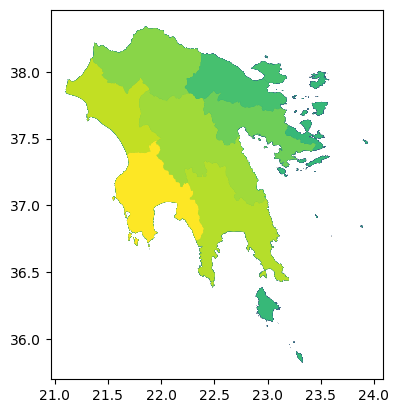

In [45]:
gdf.plot('median')